# 02 — Extração e Análise de Features
Extrai features manuais de cada imagem usando a máscara do notebook 01.

Famílias cobertas (obrigatórias pelo enunciado):
- **Forma:** área, perímetro, excentricidade, solidez, extensão, circularidade
- **Momentos de Hu:** 7 valores em escala logarítmica
- **Cor:** média e desvio padrão dos canais HSV
- **Textura:** 4 propriedades GLCM

Ao final gera `X.csv` e `y.csv`. Inclui análise intermediária: boxplots, SelectKBest e PCA.

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from skimage.feature import graycomatrix, graycoprops
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler

DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
SEED = 42

## Segmentação (mesma do notebook 01)

In [2]:
def segmentar_hsv(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([0,40,40]), np.array([180,255,255]))
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)

def segmentar_otsu(img_bgr):
    gray = cv2.GaussianBlur(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), (5,5), 0)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    return cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)

# Troque para segmentar_otsu se foi o escolhido no notebook 01
SEGMENTAR = segmentar_hsv

## Funções de extração

In [3]:
def features_forma(mask):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return {k: 0.0 for k in ['area','perimetro','excentricidade','solidez','extensao','circularidade']}
    cnt = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    peri = cv2.arcLength(cnt, True)
    circ = (4 * np.pi * area / peri**2) if peri > 0 else 0.0
    hull_area = cv2.contourArea(cv2.convexHull(cnt))
    solid = area / hull_area if hull_area > 0 else 0.0
    _,_,w,h = cv2.boundingRect(cnt)
    ext = area / (w*h) if w*h > 0 else 0.0
    if len(cnt) >= 5:
        (_,_),(ma,MA),_ = cv2.fitEllipse(cnt)
        ecc = np.sqrt(1-(min(ma,MA)/max(ma,MA))**2) if max(ma,MA)>0 else 0.0
    else:
        ecc = 0.0
    return {'area':area,'perimetro':peri,'excentricidade':ecc,'solidez':solid,'extensao':ext,'circularidade':circ}

def features_hu(mask):
    hu = cv2.HuMoments(cv2.moments(mask)).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    return {f'hu_{i+1}': v for i,v in enumerate(hu_log)}

def features_cor(img_bgr, mask):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    feats = {}
    for i, c in enumerate(['H','S','V']):
        px = hsv[:,:,i][mask>0]
        feats[f'cor_mean_{c}'] = float(px.mean()) if len(px)>0 else 0.0
        feats[f'cor_std_{c}']  = float(px.std())  if len(px)>0 else 0.0
    return feats

def features_glcm(img_bgr, mask):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray[mask==0] = 0
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    return {
        'glcm_contraste':     float(graycoprops(glcm,'contrast')[0,0]),
        'glcm_homogeneidade': float(graycoprops(glcm,'homogeneity')[0,0]),
        'glcm_energia':       float(graycoprops(glcm,'energy')[0,0]),
        'glcm_correlacao':    float(graycoprops(glcm,'correlation')[0,0])
    }

def extrair_features(path):
    img = cv2.resize(cv2.imread(str(path)), (256,256))
    mask = SEGMENTAR(img)
    feats = {}
    feats.update(features_forma(mask))
    feats.update(features_hu(mask))
    feats.update(features_cor(img, mask))
    feats.update(features_glcm(img, mask))
    feats['classe']  = path.parent.name
    feats['arquivo'] = path.name
    return feats

## Extração em batch

In [4]:
imagens = list(DATA_DIR.rglob('*.jpg')) + list(DATA_DIR.rglob('*.jpeg')) + list(DATA_DIR.rglob('*.png'))
print(f'Total: {len(imagens)} imagens')

registros = []
for i, path in enumerate(imagens):
    try:
        registros.append(extrair_features(path))
    except Exception as e:
        print(f'  Erro em {path.name}: {e}')
    if (i+1) % 50 == 0:
        print(f'  {i+1}/{len(imagens)}...')

df = pd.DataFrame(registros)
print(f'Dataset: {df.shape}')
print(df['classe'].value_counts())
df.head()

Total: 27398 imagens
  50/27398...
  100/27398...
  150/27398...
  200/27398...
  250/27398...
  300/27398...
  350/27398...
  400/27398...
  450/27398...
  500/27398...
  550/27398...
  600/27398...
  650/27398...
  700/27398...
  750/27398...
  800/27398...
  850/27398...
  900/27398...
  950/27398...
  1000/27398...
  1050/27398...
  1100/27398...
  1150/27398...
  1200/27398...
  1250/27398...
  1300/27398...
  1350/27398...
  1400/27398...
  1450/27398...
  1500/27398...
  1550/27398...
  1600/27398...
  1650/27398...
  1700/27398...
  1750/27398...
  1800/27398...
  1850/27398...
  1900/27398...
  1950/27398...
  2000/27398...
  2050/27398...
  2100/27398...
  2150/27398...
  2200/27398...
  2250/27398...
  2300/27398...
  2350/27398...
  2400/27398...
  2450/27398...
  2500/27398...
  2550/27398...
  2600/27398...
  2650/27398...
  2700/27398...
  2750/27398...
  2800/27398...
  2850/27398...
  2900/27398...
  2950/27398...
  3000/27398...
  3050/27398...
  3100/27398...
  3150/

,area,perimetro,excentricidade,solidez,extensao,circularidade,hu_1,hu_2,hu_3,hu_4,...,cor_mean_S,cor_std_S,cor_mean_V,cor_std_V,glcm_contraste,glcm_homogeneidade,glcm_energia,glcm_correlacao,classe,arquivo
0,33833.0,816.264063,0.705396,0.900137,0.590001,0.638100,3.134134,7.071233,9.764477,9.976149,...,156.610415,27.529264,232.153745,33.671040,371.836826,0.727144,0.473695,0.981553,freshbanana,rotated_by_75_Screen Shot 2018-06-12 at 9.58.0...
1,54731.5,906.055910,0.538809,0.992124,0.835136,0.837794,3.110738,7.991836,9.998789,9.990950,...,67.207791,45.295533,189.935266,24.522040,264.744838,0.782903,0.267642,0.978621,freshbanana,rotated_by_60_Screen Shot 2018-06-12 at 9.46.5...
2,25516.5,854.790972,0.649876,0.746402,0.478186,0.438845,3.073038,6.827893,9.595754,9.913744,...,146.887781,30.012009,248.956334,17.939785,446.587056,0.855289,0.603573,0.980768,freshbanana,rotated_by_30_Screen Shot 2018-06-12 at 9.49.4...
3,20434.0,889.719906,0.748113,0.560934,0.389664,0.324382,2.936425,6.918163,9.048676,9.459778,...,146.805131,33.341625,235.601518,23.413616,409.895404,0.874532,0.676792,0.977654,freshbanana,Screen Shot 2018-06-12 at 9.39.13 PM.png
4,24103.5,813.737152,0.867344,0.789619,0.448354,0.457427,2.975360,6.257546,9.381526,9.824721,...,150.165331,28.450036,237.543551,19.677517,367.952267,0.824061,0.622161,0.980357,freshbanana,rotated_by_45_Screen Shot 2018-06-12 at 10.00....


## Salva X.csv e y.csv

In [5]:
feature_cols = [c for c in df.columns if c not in ['classe','arquivo']]
X = df[feature_cols]
y = df['classe']
X.to_csv(OUTPUT_DIR / 'X.csv', index=False)
y.to_csv(OUTPUT_DIR / 'y.csv', index=False)
print(f'Salvo: X.csv {X.shape}, y.csv {y.shape}')

Salvo: X.csv (27398, 23), y.csv (27398,)


---
## Análise intermediária
### Boxplots por classe

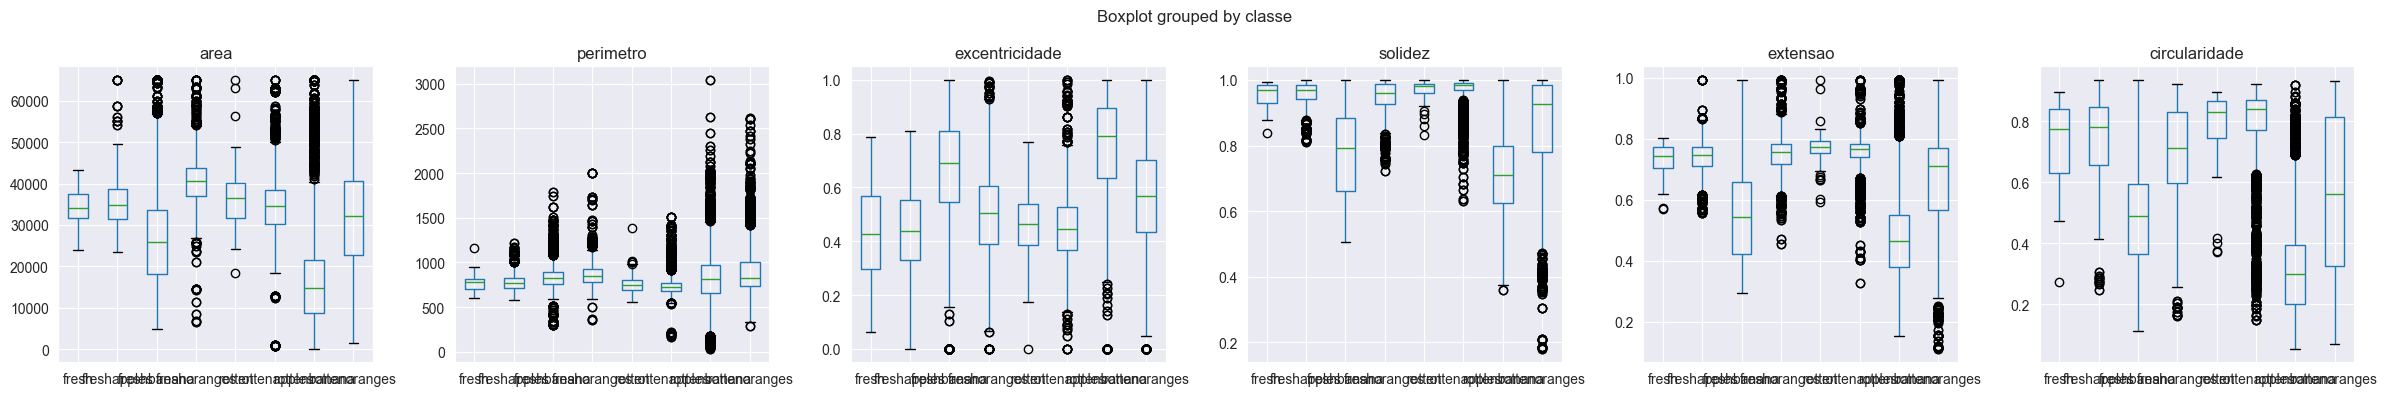

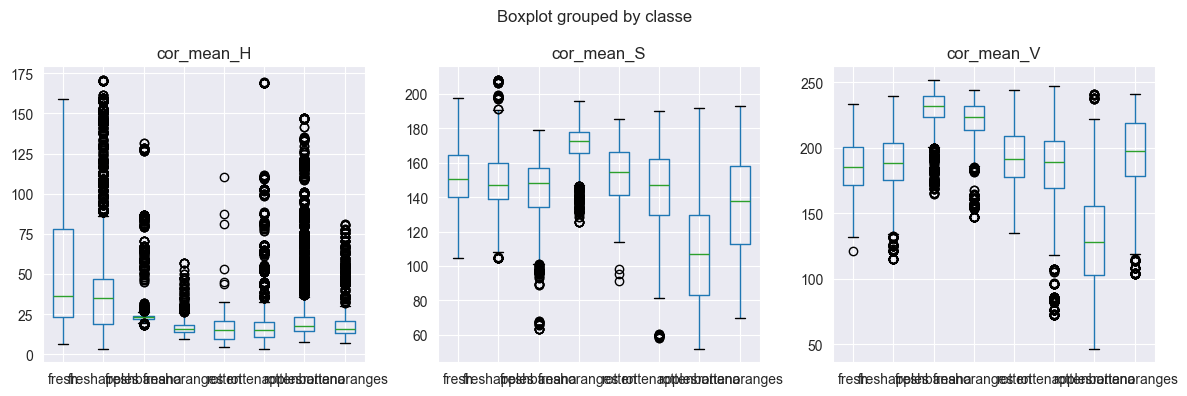

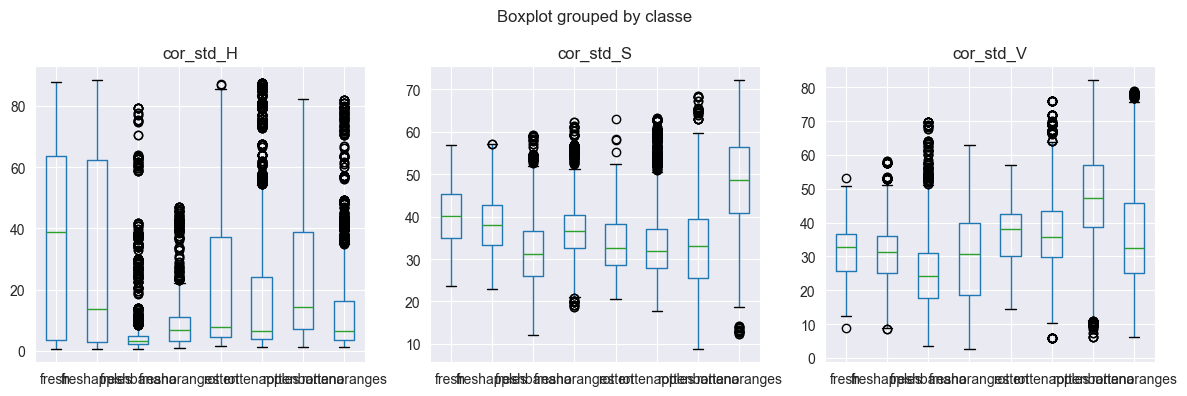

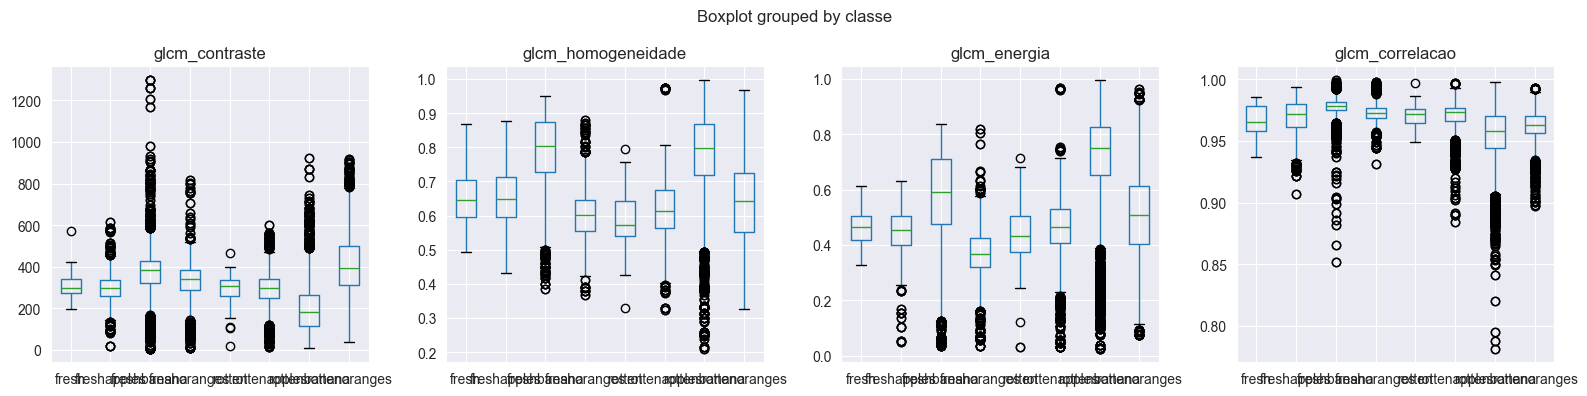

In [6]:
grupos = {
    'Forma':        ['area','perimetro','excentricidade','solidez','extensao','circularidade'],
    'Cor_media':    ['cor_mean_H','cor_mean_S','cor_mean_V'],
    'Cor_desvio':   ['cor_std_H','cor_std_S','cor_std_V'],
    'Textura_GLCM': ['glcm_contraste','glcm_homogeneidade','glcm_energia','glcm_correlacao']
}

for grupo, cols in grupos.items():
    cols = [c for c in cols if c in df.columns]
    fig, axes = plt.subplots(1, len(cols), figsize=(4*len(cols), 4))
    if len(cols)==1: axes=[axes]
    fig.suptitle(f'Boxplots — {grupo}', fontsize=12)
    for ax, col in zip(axes, cols):
        df.boxplot(column=col, by='classe', ax=ax)
        ax.set_title(col); ax.set_xlabel('')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'boxplot_{grupo}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Médias por classe

In [7]:
medias = df.groupby('classe')[feature_cols].mean().T
if 'fresh' in medias.columns and 'rotten' in medias.columns:
    medias['diff_abs'] = (medias['fresh'] - medias['rotten']).abs()
    print(medias.sort_values('diff_abs', ascending=False).round(4).to_string())

classe                   fresh  freshapples  freshbanana  freshoranges      rotten  rottenapples  rottenbanana  rottenoranges   diff_abs
area                34116.4650   34934.5084   28055.4047    40470.1467  36478.7250    34377.6529    18044.2320     31890.4567  2362.2600
cor_mean_H             52.4816      46.1712      25.3645       16.7259     18.3890       18.8764       27.0591        18.5964    34.0926
cor_std_H              37.7924      31.9599       5.9256        8.3420     21.2137       16.8847       24.1407        12.9947    16.5786
glcm_contraste        307.1671     299.3531     375.4402      333.2864    295.1508      294.1939      204.1613       414.3779    12.0162
cor_mean_V            183.6646     187.7844     229.0629      220.9843    191.8175      185.9365      129.9676       195.4421     8.1530
perimetro             771.6815     774.1205     839.2280      868.1866    765.8576      745.1958      828.3628       903.3079     5.8239
cor_std_S              40.1132      38.23

### Mapa de correlação

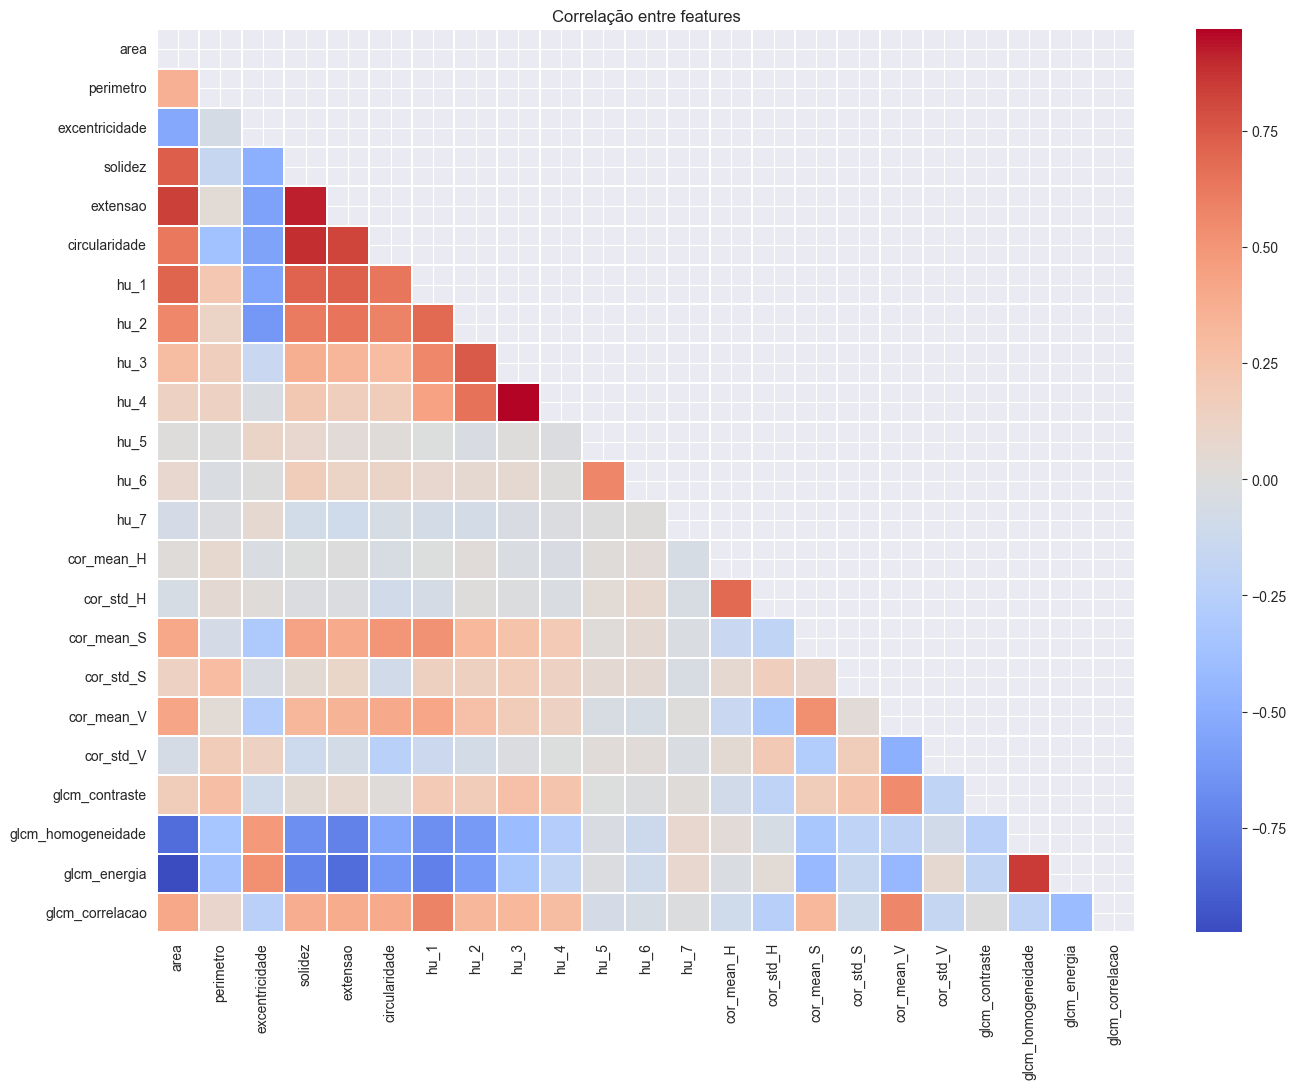

In [8]:
plt.figure(figsize=(14,11))
corr = X.corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool)),
            cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlação entre features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlacao_features.png', dpi=150)
plt.show()

### SelectKBest — top 10 features mais discriminativas

Top 10:
           feature     F_score  p_value
        cor_mean_V 6132.011524      0.0
     circularidade 4232.521437      0.0
           solidez 3750.673647      0.0
          extensao 3159.801099      0.0
              hu_1 2880.098328      0.0
        cor_mean_S 2669.420900      0.0
              hu_2 2440.310256      0.0
      glcm_energia 2232.736523      0.0
glcm_homogeneidade 2185.289404      0.0
              area 1824.262215      0.0


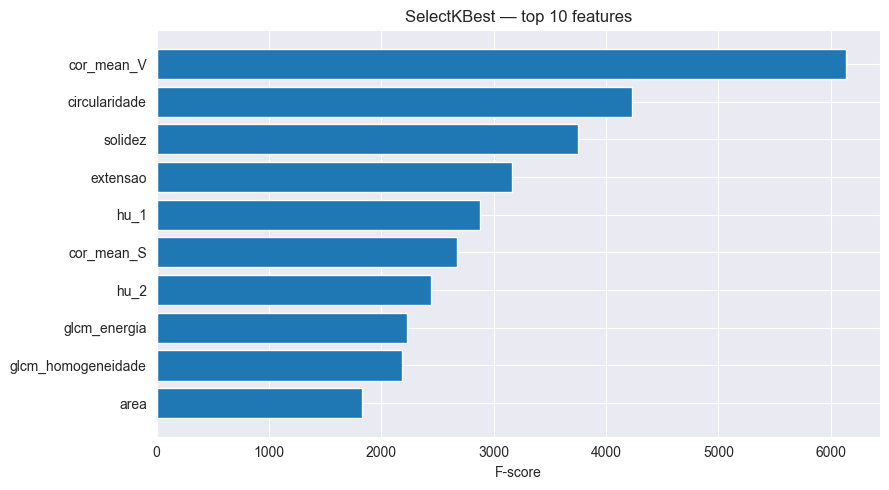


Top features: ['cor_mean_V', 'circularidade', 'solidez', 'extensao', 'hu_1', 'cor_mean_S', 'hu_2', 'glcm_energia', 'glcm_homogeneidade', 'area']


In [9]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X.fillna(0), y_enc)

scores_df = pd.DataFrame({'feature': feature_cols, 'F_score': selector.scores_, 'p_value': selector.pvalues_})
scores_df = scores_df.sort_values('F_score', ascending=False)
print('Top 10:')
print(scores_df.head(10).to_string(index=False))

top10 = scores_df.head(10)
plt.figure(figsize=(9,5))
plt.barh(top10['feature'][::-1], top10['F_score'][::-1])
plt.xlabel('F-score'); plt.title('SelectKBest — top 10 features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'selectkbest_top10.png', dpi=150)
plt.show()

TOP_FEATURES = scores_df.head(10)['feature'].tolist()
print(f'\nTop features: {TOP_FEATURES}')

### PCA — visualização 2D

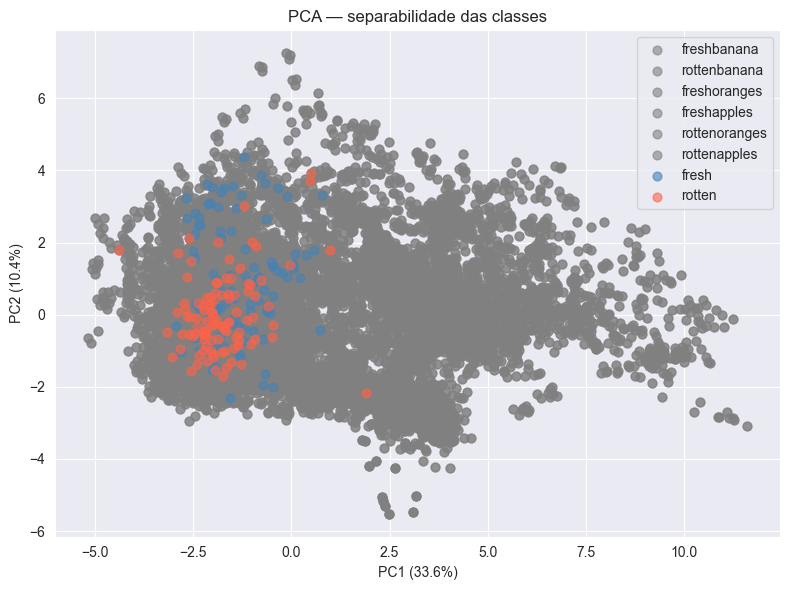

Variância explicada: 44.0%


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.fillna(0))
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
cores = {'fresh':'steelblue','rotten':'tomato'}
for classe in y.unique():
    idx = (y == classe).values
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=classe, alpha=0.6, s=40, color=cores.get(classe,'gray'))
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — separabilidade das classes')
plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pca_classes.png', dpi=150)
plt.show()
print(f'Variância explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%')